<h1 align="center">CLUSTERING ASSIGNMENT</h1>

***Objective:***
*The objective of this assessment is to evaluate your understanding and ability to apply clustering
techniques to a real-world dataset.*

**Dataset**
Use the Iris dataset available in the sklearn library.

**Key components to be fulfilled :**

***Loading and Preprocessing***

*● Load the Iris dataset from sklearn.*
*● Drop the species column since this is a clustering problem.*
*Clustering Algorithm Implementation: Implement the following two clustering algorithms:*

1. KMeans Clustering:
● Provide a brief description of how KMeans clustering works.
● Explain why KMeans clustering might be suitable for the Iris dataset.
● Apply KMeans clustering to the preprocessed Iris dataset and visualize the clusters.

3. Hierarchical Clustering:
● Provide a brief description of how Hierarchical clustering works.
● Explain why Hierarchical clustering might be suitable for the Iris dataset.
● Apply Hierarchical clustering to the preprocessed Iris dataset and visualize the clusters.

# 1. Import Libraries

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

#Import libraries
import numpy as np
import pandas as pd

#Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

#import dataset
from sklearn.datasets import load_iris

#Feature Scaling
from sklearn.preprocessing import StandardScaler

#clustering algorithms library
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram,linkage

# 2.Load the iris dataset

In [2]:
#Load dataset
data=load_iris()
X=pd.DataFrame(data.data,columns=data.feature_names)
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


# 3.Preprocessing

In [3]:
X.info()
X.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
#Checking missing values
X.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

*Observations*
1. No missing values found.
2. Features have very different scales . So scaling is to be done.
3. Species column is dropped as clustering is to be done. Since clustering is unsupervised learning, we do not use the species labels.

# 4. Feature Scaling

In [8]:
#Feature scaling using Standard Scaler to make mean=0 and std=1
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
print("Mean after scalin

# Dimensionality Reduction using Principal Component Analysis
*PCA (Principal Component Analysis) is a dimensionality reduction technique and helps us to reduce the number of features in a dataset while keeping the most important information. It changes complex datasets by transforming correlated features into a smaller set of uncorrelated components.*
*PCA uses linear algebra to transform data into new features called principal components. It finds these by calculating eigenvectors (directions) and eigenvalues (importance) from the covariance matrix. PCA selects the top components with the highest eigenvalues and projects the data onto them simplify the dataset.*

In [20]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)
print("Explained Variance ratio",pca.explained_variance_ratio_)

Explained Variance ratio [0.72962445 0.22850762]


# 5. K-Means Clustering
*K-Means is a centroid-based clustering algorithm.*
*steps of algorithm:*
1. Choose K clusters.
2. Randomly initialize K centroids.
3. Assign each point to the nearest centroid.
4. Update centroid positions.
5. Repeat until centroids stop changing.

*K-Means is suitable for the Iris dataset because iris has naturally occurring groups.
The dataset is small and has numerical features only. Euclidean distance is used to find the distance.*


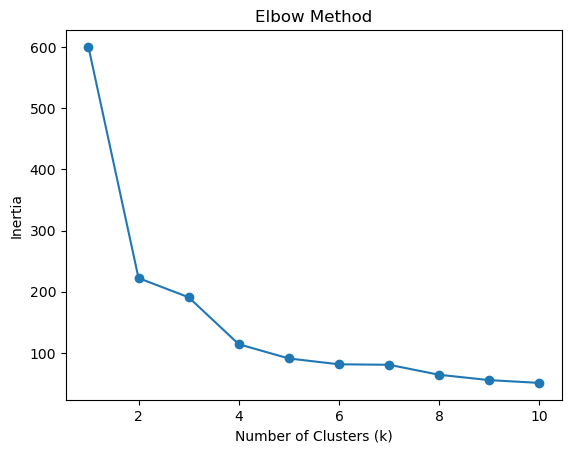

In [10]:
#Elbow method to find k value
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

**Observation**
*The elbow plot shows a sharp decrease at k = 3, after that the decrease becomes more gradual. So, we choose K=3, which also matches the three natural species present in the Iris dataset.*

In [12]:
#Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

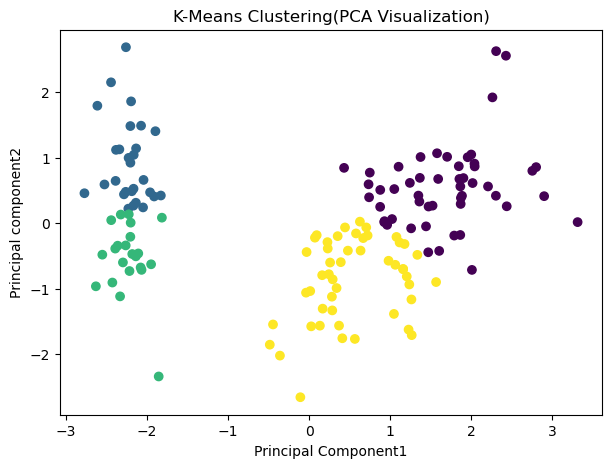

In [13]:
#Visualize K-Means Clusters
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0],X_pca[:,1],c=clusters,cmap='viridis')
plt.xlabel("Principal Component1")
plt.ylabel("Principal component2")
plt.title("K-Means Clustering(PCA Visualization)")
plt.show()

**Interpretation**
1. Different colors represent different clusters.
2. Three different clusters are found here.
3. K-Means separates similar flowers based on feature similarity.
4. We can see more variance along Principal Component1.

In [14]:
#cluster assignment
print("cluster labels assigned:\n", clusters)

cluster labels assigned:
 [1 2 2 2 1 1 2 1 2 2 1 2 2 2 1 1 1 1 1 1 1 1 1 2 2 2 1 1 1 2 2 1 1 1 2 2 1
 1 2 1 1 2 2 1 1 2 1 2 1 2 0 0 0 3 3 3 0 3 0 3 3 3 3 3 3 0 3 3 3 3 0 3 3 3
 3 0 0 0 3 3 3 3 3 3 3 0 0 3 3 3 3 3 3 3 3 3 3 3 3 3 0 3 0 0 0 0 3 0 0 0 0
 0 0 3 0 0 0 0 0 3 0 3 0 3 0 0 3 0 0 0 0 0 0 3 3 0 0 0 0 0 0 0 3 0 0 0 3 0
 0 0]


# 6. Hierarchial Agglomerative Clustering
*It is also known as the bottom-up approach or hierarchical agglomerative clustering (HAC). Bottom-up algorithms treat each data as a singleton cluster at the outset and then successively agglomerate pairs of clusters until all clusters have been merged into a single cluster that contains all data.*
*Steps of Agglomerative Clustering*
1. Start with each data point as its own cluster.
2. Compute distances between all clusters.
3. Merge the two closest clusters based on a linkage method.
4. Update the distances to reflect the new cluster.
5. Repeat merging until the desired number of clusters or one cluster remains.
6. The dendrogram visualizes these merges as a tree, showing cluster relationships and distances.

*This is suitable for Iris because*
1. No random initialization as that of K-means.
2. This gives a dendrogram to visualize.
3. Helps us to understand the relationships among various clusters.


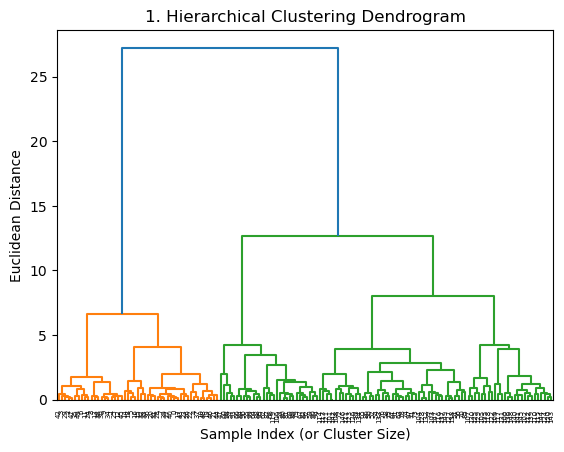

In [15]:
# Plot the Dendrogram to determine the number of clusters
# 'ward' linkage minimizes the variance within each cluster
linkage_matrix = linkage(X_scaled, method='ward')
dendrogram(linkage_matrix)
plt.title("1. Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index (or Cluster Size)")
plt.ylabel("Euclidean Distance")
plt.show()

In [16]:
#Apply Agglomerative Hierarchical Clustering
# Based on the dendrogram, we choose 3 clusters
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
cluster_labels = hc.fit_predict(X_scaled)

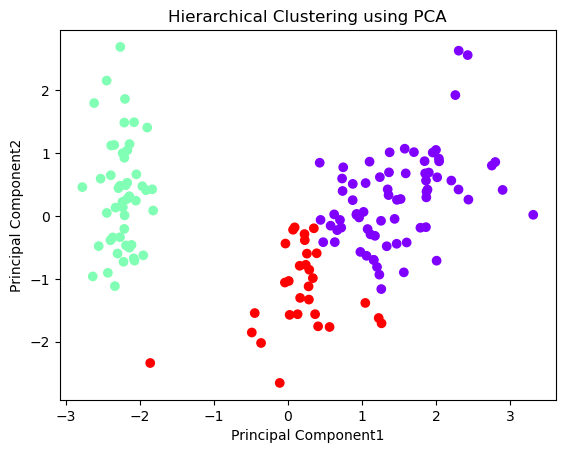

In [17]:
#Scatterplot of clusters
plt.scatter(X_pca[:,0],X_pca[:,1],c=cluster_labels,cmap='rainbow')
plt.xlabel("Principal Component1")
plt.ylabel("Principal Component2")
plt.title("Hierarchical Clustering using PCA")
plt.show()

*Interpretation*

*The clusters are formed based on hierarchical merging instead of centroids.*
*Samples with similar characteristics appear in the same color.*

In [18]:
print("cluster labels assigned:\n", cluster_labels)

cluster labels assigned:
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 2 1 1 1 1 1 1 1 1 0 0 0 2 0 2 0 2 0 2 2 0 2 0 2 0 2 2 2 2 0 0 0 0
 0 0 0 0 0 2 2 2 2 0 2 0 0 2 2 2 2 0 2 2 2 2 2 0 2 2 0 0 0 0 0 0 2 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


# Conclusion

*Both K-Means and Hierarchical Clustering successfully grouped the Iris dataset into three clusters. K-Means is computationally efficient and works well when the number of clusters is known. Hierarchical Clustering provides a dendrogram that helps visualize the relationships among data points and determine the optimal number of clusters. Since the Iris dataset is small and contains naturally separable groups, both algorithms perform effectively.*